In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_odds_categories.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""genomic_region""","""mane_cds""","""#E31A1C""","""MANE CDS""",1
"""genomic_region""","""non_mane_cds""","""#FB9A99""","""Other CDS""",1
"""genomic_region""","""mane_exonic""","""#33A02C""","""MANE Exon""",1
"""genomic_region""","""non_mane_exonic""","""#B2DF8A""","""Other Exon""",1
"""plof""","""loftee_hc""","""#990000""","""LOFTEE HC""",1
…,…,…,…,…
"""encode_enhancer""","""encode_ca_ctcf""","""#4DAF4A""","""Accessible Region with CTCF Bi…",1
"""encode_enhancer""","""encode_ca""","""#377EB8""","""Chromatin Accessible""",1
"""encode_enhancer""","""encode_ca_tf""","""#1D6498""","""Accessible Region with TF Bind…",1


In [3]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_251124.parquet")
# anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_251124_fillna.parquet")

min_range = -5_000
max_range = +0

anno = (
    anno
    .filter(
        # Choose CDS
        # (pl.col('mane_cds') == True)
        # ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True))
        # (pl.col('non_mane_cds') == False)

        # Choose non CDS variants
        # (pl.col('consequence_intron_variant') == True)
        (pl.col('consequence_downstream_gene_variant')==True)

        # (pl.col('dist_to_tss') < max_range) &
        # (pl.col('dist_to_tss') > min_range)
        
        # Only Gene body
        # (pl.col('consequence_upstream_gene_variant') == 0) &
        # (pl.col('consequence_downstream_gene_variant') == 0)
    )
    .with_columns(
        encode_annotated = pl.col('not_in_encode')==False,
        insertion = pl.when(pl.col('ref').str.len_chars() < pl.col('alt').str.len_chars()).then(True).otherwise(False),
        deletion = pl.when(pl.col('ref').str.len_chars() > pl.col('alt').str.len_chars()).then(True).otherwise(False),
    )
    .with_columns(
        # --- Indel CDS categories ---
        deletion_x3bp = pl.when(pl.col('deletion') & (pl.col('variant_length') - 1) %3 ==0).then(True).otherwise(False),
        deletion_not_x3bp = pl.when(pl.col('deletion') & (pl.col('variant_length') - 1) %3 !=0).then(True).otherwise(False),
        insertion_x3bp = pl.when(pl.col('insertion') & (pl.col('variant_length') - 1) %3 ==0).then(True).otherwise(False),
        insertion_not_x3bp = pl.when(pl.col('insertion') & (pl.col('variant_length') - 1) %3 !=0).then(True).otherwise(False),

        # --- Indel length categories ---
        deletion_1bp = pl.when(pl.col('variant_length') == 2).then(True).otherwise(False) & pl.col('deletion'),
        deletion_2_3bp = pl.when((pl.col('variant_length') >= 3) & (pl.col('variant_length') <= 4)).then(True).otherwise(False) & pl.col('deletion'),
        deletion_4_10bp = pl.when((pl.col('variant_length') >= 5) & (pl.col('variant_length') <= 10)).then(True).otherwise(False) & pl.col('deletion'),
        deletion_11_50bp = pl.when((pl.col('variant_length') >= 11) & (pl.col('variant_length') <= 50)).then(True).otherwise(False) & pl.col('deletion'),
        deletion_50bp = pl.when(pl.col('variant_length')  > 50).then(True).otherwise(False) & pl.col('deletion'),

        insertion_1bp = pl.when(pl.col('variant_length') == 2).then(True).otherwise(False) & pl.col('insertion'),
        insertion_2_3bp = pl.when((pl.col('variant_length') >= 3) & (pl.col('variant_length') <= 4)).then(True).otherwise(False) & pl.col('insertion'),
        insertion_4_10bp = pl.when((pl.col('variant_length') >= 5) & (pl.col('variant_length') <= 10)).then(True).otherwise(False) & pl.col('insertion'),
        insertion_11_50bp = pl.when((pl.col('variant_length') >= 11) & (pl.col('variant_length') <= 50)).then(True).otherwise(False) & pl.col('insertion'),
        insertion_50bp = pl.when(pl.col('variant_length')  > 50).then(True).otherwise(False) & pl.col('insertion'),
    )
)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

insertion,deletion_50bp,mane_exonic,insertion_11_50bp,non_mane_exonic,deletion_2_3bp,encode_tf,five_prime_utr_variant_consequence_ustop_gained,insertion_50bp,insertion_not_x3bp,deletion,encode_ca_ctcf,non_mane_cds,mane_cds,consequence_splice_donor_variant,deletion_1bp,insertion_1bp,dist_to_tss,deletion_not_x3bp,encode_pels,encode_ca_h3k4me3,strand,consequence_splice_acceptor_variant,not_in_encode,gene_name,encode_dels,consequence_frameshift_variant,gene_length,consequence_start_lost,insertion_x3bp,encode_ca_tf,region,deletion_4_10bp,consequence_missense_variant,insertion_4_10bp,id,loftee_hc,five_prime_utr_variant_consequence_uaug_gained,encode_pls,consequence_stop_lost,encode_annotated,tss,five_prime_utr_variant_consequence_uframeshift,five_prime_utr_variant_consequence_ustop_lost,consequence_stop_gained,deletion_x3bp,deletion_11_50bp,five_prime_utr_variant_consequence_uaug_lost,encode_ca,insertion_2_3bp
bool,bool,bool,bool,bool,bool,bool,u8,bool,bool,bool,bool,bool,bool,i32,bool,bool,i64,bool,bool,bool,str,i32,bool,str,bool,i32,i64,i32,bool,bool,str,bool,i32,bool,str,i8,u8,bool,i32,bool,i64,u8,u8,i32,bool,bool,u8,bool,bool
false,false,false,false,false,false,false,null,false,false,false,false,false,false,0,false,false,150050,false,false,false,"""-1""",0,false,"""ABCA1""",true,0,147151,0,true,false,"""ENSG00000165029""",false,0,false,"""chr9:104778105:T:C""",0,null,false,0,true,104928155,null,null,0,true,false,null,false,false
false,false,true,false,false,false,false,null,false,false,false,false,false,false,0,false,false,151610,false,false,false,"""-1""",0,false,"""ABCA1""",true,0,147151,0,true,false,"""ENSG00000165029""",false,0,false,"""chr9:104776545:G:A""",0,null,false,0,true,104928155,null,null,0,true,false,null,false,false
false,false,false,false,false,false,false,null,false,false,false,false,false,false,0,false,false,147937,false,false,false,"""-1""",0,false,"""ABCA1""",true,0,147151,0,true,false,"""ENSG00000165029""",false,0,false,"""chr9:104780218:T:C""",0,null,false,0,true,104928155,null,null,0,true,false,null,false,false
false,false,true,false,false,false,false,null,false,false,false,false,false,false,0,false,false,152054,false,false,false,"""-1""",0,false,"""ABCA1""",true,0,147151,0,true,false,"""ENSG00000165029""",false,0,false,"""chr9:104776101:C:T""",0,null,false,0,true,104928155,null,null,0,true,false,null,false,false
false,false,true,false,false,false,false,null,false,false,false,false,false,false,0,false,false,151563,false,false,false,"""-1""",0,false,"""ABCA1""",true,0,147151,0,true,false,"""ENSG00000165029""",false,0,false,"""chr9:104776592:C:T""",0,null,false,0,true,104928155,null,null,0,true,false,null,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
true,false,false,true,false,false,false,null,false,true,false,false,false,false,0,false,false,29711,false,false,false,"""-1""",0,true,"""PRC1""",false,0,29591,0,false,false,"""ENSG00000198901""",false,0,false,"""chr15:90965918:A:AAAATCACACTCC…",0,null,false,0,false,90995629,null,null,0,true,false,null,false,false
false,false,true,false,false,false,false,null,false,false,true,false,false,false,0,false,false,10604,false,false,false,"""1""",0,true,"""CHTF18""",false,0,12693,0,true,false,"""ENSG00000127586""",false,0,false,"""chr16:798649:CTTACAAGATGGTGG:C""",0,null,false,0,false,788045,null,null,0,true,true,null,false,false
false,false,true,false,false,false,false,null,false,false,true,false,false,false,0,true,false,8338,true,false,false,"""1""",0,true,"""GPT""",false,0,4203,0,true,false,"""ENSG00000167701""",false,0,false,"""chr8:144511310:TA:T""",0,null,false,0,false,144502972,null,null,0,false,false,null,false,false


In [4]:
selected_annos = anno_config_df.filter(
    # pl.col('category').is_in(['genomic_region']) # genomic_region
    pl.col('category').is_in(['indel_length']) # indel length
    # pl.col('category').is_in(['indel_cds']) # indel length
    # pl.col('category').is_in(['encode_enhancer']) # upstream
    # pl.col('category').is_in(['encode_boolean', 'indel_categories']) # upstream
    # pl.col('category').is_in(['indel_categories', 'plof', 'missense']) # CDS
    # pl.col('category').is_in(['indel_categories', '5utr_annotator', 'encode_boolean']) # 5utr
)['annotation'].to_list()

melted_anno = (
    anno

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]),
        on="annotation",
        how="left"
    )
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir")
    )

    # .drop_nulls()
    # .filter(pl.col('annotation_score').is_not_null())
)

melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor
str,str,str,f32,str,i64,f64
"""chr9:104778105:T:C""","""ENSG00000165029""","""deletion_1bp""",0.0,"""indel_length""",1,0.0
"""chr9:104776545:G:A""","""ENSG00000165029""","""deletion_1bp""",0.0,"""indel_length""",1,0.0
"""chr9:104780218:T:C""","""ENSG00000165029""","""deletion_1bp""",0.0,"""indel_length""",1,0.0
"""chr9:104776101:C:T""","""ENSG00000165029""","""deletion_1bp""",0.0,"""indel_length""",1,0.0
"""chr9:104776592:C:T""","""ENSG00000165029""","""deletion_1bp""",0.0,"""indel_length""",1,0.0
…,…,…,…,…,…,…
"""chr15:90965918:A:AAAATCACACTCC…","""ENSG00000198901""","""insertion_50bp""",0.0,"""indel_length""",1,0.0
"""chr16:798649:CTTACAAGATGGTGG:C""","""ENSG00000127586""","""insertion_50bp""",0.0,"""indel_length""",1,0.0
"""chr8:144511310:TA:T""","""ENSG00000167701""","""insertion_50bp""",0.0,"""indel_length""",1,0.0


In [5]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
        .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)

# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [6]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)

# gene_trait_df = gene_trait_df.head()
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


In [7]:
n_steps = 101
or_threshold_pheno_high = 0.9
or_threshold_pheno_low = 1e-4

cutoffs_list = 1 - np.logspace(
    np.log10(or_threshold_pheno_low),
    np.log10(or_threshold_pheno_high),
    num=n_steps
)

pheno_cutoffs_lazy = pl.LazyFrame({"pheno_cutoff": cutoffs_list.tolist()})

pheno_cutoffs_lazy.collect()

pheno_cutoff
f64
0.9999
0.99989
0.99988
0.999869
0.999856
…
0.374722
0.315119
0.249834


In [8]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())

# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    # Select required variants
    .join(
        anno_ids_lazy, 
        on="id", 
        how="semi"
    )
    # Merge annotation scores
    .join(
        melted_anno.lazy(),
        on="id", 
        how="inner"
    )
    # Merge with gene_trait_df
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('corr_dir') == -1) # To get 1/100, 1/1000, etc.
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
    
    # Cross join with cutoffs and compute odds ratios
    .join(
        pheno_cutoffs_lazy, 
        how="cross"
    )
    .group_by(["annotation", "region", "gene_name", "phenotype", "pheno_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor") == 1) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= pl.col("pheno_cutoff"))
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor") == 1) & 
            (pl.col("mean_pheno_value_dircor_ptile") < pl.col("pheno_cutoff"))
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor") == 0) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= pl.col("pheno_cutoff"))
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor") == 0) & 
            (pl.col("mean_pheno_value_dircor_ptile") < pl.col("pheno_cutoff"))
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = gp_lazy.collect(engine='streaming').sort('pheno_cutoff')

or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,pheno_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""deletion_1bp""","""ENSG00000084674""","""APOB""","""alanine_aminotransferase_int""",0.1,40,6,1116,125,0.746714
"""insertion_11_50bp""","""ENSG00000167701""","""GPT""","""alanine_aminotransferase_int""",0.1,8,2,1766,174,0.394111
"""deletion_11_50bp""","""ENSG00000010327""","""STAB1""","""albumin_int""",0.1,5,0,1130,128,inf
"""insertion_11_50bp""","""ENSG00000166278""","""C2""","""albumin_int""",0.1,0,0,985,134,NaN
"""deletion_1bp""","""ENSG00000120341""","""SEC16B""","""alkaline_phosphatase_int""",0.1,56,5,1845,208,1.262656
…,…,…,…,…,…,…,…,…,…
"""deletion_2_3bp""","""ENSG00000139044""","""B4GALNT3""","""alkaline_phosphatase_int""",0.9999,0,25,0,1182,NaN
"""deletion_50bp""","""ENSG00000165029""","""ABCA1""","""apolipoprotein_a_int""",0.9999,0,0,0,1077,NaN
"""insertion_50bp""","""ENSG00000080345""","""RIF1""","""arm_fat_mass_left_int""",0.9999,0,1,1,3787,0.0


In [9]:
# or_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_all_vars_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

print('unique percentile cutoffs:', or_df['pheno_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['pheno_cutoff', 'annotation']),
        pheno_cutoff_inv = 1 - pl.col('pheno_cutoff'),
    )
    .with_columns(
        neg_log_pheno_cutoff_inv = -np.log10(pl.col('pheno_cutoff_inv')),
        med_odds_ratio = pl.col('odds_ratio').median().over(['pheno_cutoff_inv', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['pheno_cutoff_inv', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['pheno_cutoff_inv', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'neg_log_pheno_cutoff_inv', 'pheno_cutoff', 'pheno_cutoff_inv', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    
    # join plotting info
    .join(
        anno_config_df.select(['annotation', 'color', 'label']),
        on='annotation',
        how='left'
    )
    .sort('pheno_cutoff_inv')
)

plt_df

unique percentile cutoffs: 101


annotation,neg_log_pheno_cutoff_inv,pheno_cutoff,pheno_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,f64,f64,u64,f64,f64,f64,f64,f64,str,str
"""deletion_2_3bp""",4.0,0.9999,0.0001,140,0.0,0.0,0.0,0.0,0.0,"""#74C476""","""2-3bp Deletion"""
"""insertion_11_50bp""",4.0,0.9999,0.0001,135,0.0,0.0,0.0,0.0,0.0,"""#3182BD""","""11-50bp Insertion"""
"""insertion_2_3bp""",4.0,0.9999,0.0001,145,0.0,0.0,0.0,0.0,0.0,"""#9ECAE1""","""2-3bp Insertion"""
"""insertion_50bp""",4.0,0.9999,0.0001,56,0.0,0.0,0.0,0.0,0.0,"""#08519C""",""">50bp Insertion"""
"""deletion_11_50bp""",4.0,0.9999,0.0001,144,0.0,0.0,0.0,0.0,0.0,"""#238B45""","""11-50bp Deletion"""
…,…,…,…,…,…,…,…,…,…,…,…
"""insertion_4_10bp""",0.045757,0.1,0.9,741,0.724932,0.889921,0.021992,0.933025,0.846817,"""#6BAED6""","""4-10bp Insertion"""
"""insertion_11_50bp""",0.045757,0.1,0.9,505,0.502304,0.730477,0.032347,0.793876,0.667078,"""#3182BD""","""11-50bp Insertion"""
"""insertion_50bp""",0.045757,0.1,0.9,68,0.226427,0.359041,0.052322,0.461592,0.25649,"""#08519C""",""">50bp Insertion"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10


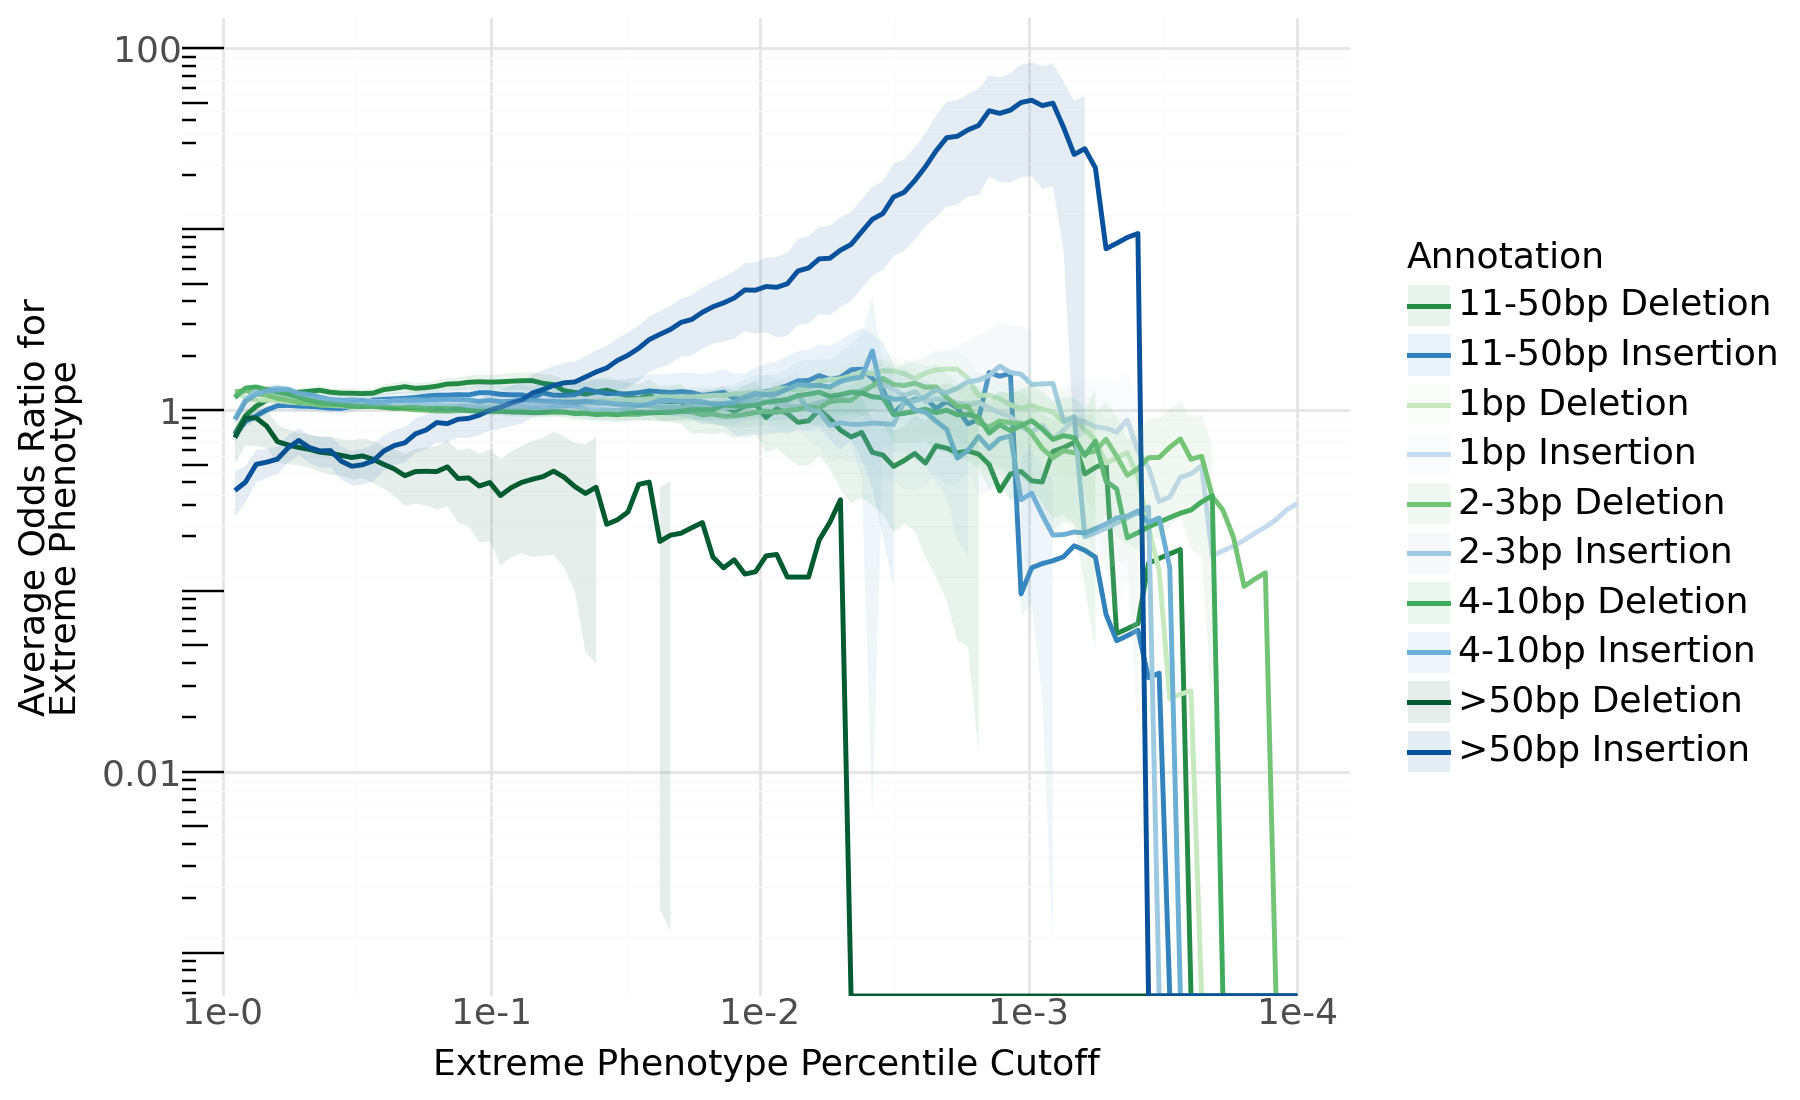

In [10]:
# Generate breaks and labels for x-axis
start_exp = int(-np.log10(or_threshold_pheno_high))
end_exp = int(-np.log10(or_threshold_pheno_low))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e-{b}" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))

(
    ggplot(
        plt_df,
        aes(x='neg_log_pheno_cutoff_inv', y='avg_odds_ratio')
    )
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        y=f"Average Odds Ratio for\nExtreme Phenotype",
        x="Extreme Phenotype Percentile Cutoff",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + annotation_logticks(sides="l")
    + theme_minimal()
    + theme(
        figure_size=(9, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)

In [11]:
plt_df.sort('avg_odds_ratio')

annotation,neg_log_pheno_cutoff_inv,pheno_cutoff,pheno_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,f64,f64,u64,f64,f64,f64,f64,f64,str,str
"""deletion_2_3bp""",4.0,0.9999,0.0001,140,0.0,0.0,0.0,0.0,0.0,"""#74C476""","""2-3bp Deletion"""
"""insertion_11_50bp""",4.0,0.9999,0.0001,135,0.0,0.0,0.0,0.0,0.0,"""#3182BD""","""11-50bp Insertion"""
"""insertion_2_3bp""",4.0,0.9999,0.0001,145,0.0,0.0,0.0,0.0,0.0,"""#9ECAE1""","""2-3bp Insertion"""
"""insertion_50bp""",4.0,0.9999,0.0001,56,0.0,0.0,0.0,0.0,0.0,"""#08519C""",""">50bp Insertion"""
"""deletion_11_50bp""",4.0,0.9999,0.0001,144,0.0,0.0,0.0,0.0,0.0,"""#238B45""","""11-50bp Deletion"""
…,…,…,…,…,…,…,…,…,…,…,…
"""insertion_50bp""",2.932355,0.998831,0.001169,327,0.0,45.537309,14.004595,72.986314,18.088304,"""#08519C""",""">50bp Insertion"""
"""insertion_50bp""",3.050982,0.999111,0.000889,289,0.0,48.243945,16.082398,79.765444,16.722445,"""#08519C""",""">50bp Insertion"""
"""insertion_50bp""",3.090524,0.999188,0.000812,280,0.0,49.794643,16.59192,82.314806,17.274479,"""#08519C""",""">50bp Insertion"""
